## **Parte I: Familiarinzandonos con la base EPH y limipieza**

### **Punto 1** 

El INDEC identifica a las personas pobres en Argentina a partir de la medición de la pobreza por ingresos. El procedimiento se basa en comparar los ingresos del hogar con el costo de la Canasta Básica Total (CBT):

Canasta Básica Alimentaria (CBA): define la línea de indigencia. Incluye solo alimentos que cubren un umbral mínimo de necesidades energéticas y proteicas. Un hogar es indigente si sus ingresos no alcanzan para cubrir la CBA.

Canasta Básica Total (CBT): amplía la CBA incorporando bienes y servicios no alimentarios (vestimenta, transporte, educación, salud, etc.).Un hogar es pobre no indigente si sus ingresos superan la CBA pero no alcanzan la CBT. 

### **Punto 2**

Entren a la página https://www.indec.gob.ar/ y vayan a la sección
Servicios y Herramientas → Bases de datos. Descarguen la base de
microdatos de la Encuesta Permanente de Hogares (EPH)
correspondiente al primer trimestre de 2005 y 2025 en formato .dta y
.xls, respectivamente (una vez descargadas, las bases a usar deberán
llamarse usu_individual_T105.dta y
usu_individual_T125.xls). En la página web, también encontrará
un diccionario de variables con el nombre de “Diseño de registro y
estructura para las bases preliminares (hogares y personas)”.
Descarguen el diccionario de cada año (los de 2005 y 2025). En estos
archivos se les indica qué significa cada variable que aparece en la
base de datos, en particular, en la sección de Diseño de registros de la
base Personas.

a. A partir de ahora, cada grupo debe decidir trabajar con una
región del país en específico y mantener dicha región en los
próximos trabajos prácticos (ver variable REGION). Eliminen los
datos de todas aquellas regiones que no se encuentren dentro
de su región y unan ambos trimestres (2005 y 2025) en una
sola base.

b. Asegúrense de que todas las variables tengan el formato
correcto. Seleccione 15 variables de interés (entre las
cuales tienen que estar: CH04, CH06, CH07, CH08,
NIVEL ED, ESTADO, CAT_INAC, IPCF) y reporten en una
figura de heatmap la cantidad de valores faltantes para cada
año (NA, o NaN en Python) en una tabla por cada año.
Comenten qué variables de las 15 que seleccionaron tienen más
valores faltantes y qué año.

c. Corregir variables si notan valores sin sentido (como ingresos
negativos) de acuerdo a la documentación de la EPH (puede ser una codificación de no respuesta de los individuos) y eliminen
estos valores extraños de sus 15 variables de interés. Comenten
brevemente en el reporte dicho proceso de limpieza.

In [1]:
import pandas as pd
import os

In [2]:
# reemplazar x la ruta de cada uno
df = pd.read_excel("C:/Users/loloa/OneDrive/Escritorio/facu/Ciencia de datos/tp/Ciencia-de-Datos/usu_individual_T125.xlsx") 

print(df.head())

                          CODUSU  ANO4  TRIMESTRE  NRO_HOGAR  COMPONENTE  H15  \
0  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           2    1   
1  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           3    0   
2  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           4    0   
3  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           5    0   
4  TQRMNOUPQHLOLOCDEFKID00851757  2025          1          1           1    1   

   REGION MAS_500  AGLOMERADO  PONDERA  ...  V21_03_M  V22_01_M V22_02_M  \
0      43       S           4      927  ...         0         0        0   
1      43       S           4      927  ...         0         0        0   
2      43       S           4      927  ...         0         0        0   
3      43       S           4      927  ...         0         0        0   
4      43       S           4     1294  ...         0         0        0   

   V22_03_M  P_DECCF  P_RDECCF  P_GDECCF  P_PDECCF  P_ID

In [3]:
statta = pd.read_stata("Individual_t105.dta")
print(statta.head())


     CODUSU  nro_hogar componente  h15    ano4       trimestre  \
0  125098          1.0        1.0   Sí  2005.0  1er. Trimestre   
1  125188          1.0        1.0   Sí  2005.0  1er. Trimestre   
2  125188          1.0        2.0   Sí  2005.0  1er. Trimestre   
3  125188          1.0        3.0  0.0  2005.0  1er. Trimestre   
4  125242          1.0        1.0   Sí  2005.0  1er. Trimestre   

              region mas_500              aglomerado  pondera  ... deccfr  \
0  Gran Buenos Aires       S  Ciudad de Buenos Aires   1017.0  ...     08   
1  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...     02   
2  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...     02   
3  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...     02   
4  Gran Buenos Aires       S  Ciudad de Buenos Aires   1103.0  ...     09   

  ideccfr rdeccfr gdeccfr pdeccfr adeccfr pj1_1 pj2_1 pj3_1 idimpp  
0              07      08              05   0.0   0.0   0.0  00000  
1 

In [4]:
print(statta.columns)  # Mostrar las columnas del DataFrame
print(statta.shape)    # Mostrar la forma del DataFrame (filas, columnas)
print(statta["region"].unique())


Index(['CODUSU', 'nro_hogar', 'componente', 'h15', 'ano4', 'trimestre',
       'region', 'mas_500', 'aglomerado', 'pondera',
       ...
       'deccfr', 'ideccfr', 'rdeccfr', 'gdeccfr', 'pdeccfr', 'adeccfr',
       'pj1_1', 'pj2_1', 'pj3_1', 'idimpp'],
      dtype='object', length=176)
(47030, 176)
['Gran Buenos Aires', 'NOA', 'NEA', 'Cuyo', 'Pampeana', 'Patagónica']
Categories (6, object): ['Gran Buenos Aires' < 'NOA' < 'NEA' < 'Cuyo' < 'Pampeana' < 'Patagónica']


In [5]:
print(df.columns)  # Mostrar las columnas del DataFrame
print(df.shape)    # Mostrar la forma del DataFrame (filas, columnas)
print(df["REGION"].unique()) 
#43 es pampeana


Index(['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'H15',
       'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA',
       ...
       'V21_03_M', 'V22_01_M', 'V22_02_M', 'V22_03_M', 'P_DECCF', 'P_RDECCF',
       'P_GDECCF', 'P_PDECCF', 'P_IDECCF', 'P_ADECCF'],
      dtype='object', length=235)
(45425, 235)
[43 41 42 40 44  1]


In [6]:
#Nos quedamos solo con la región pampeana
df_pampeana2025 = df[df['REGION'] == 43]
print(df_pampeana2025.head())

statta_pampeana2005 = statta[statta['region'] =="Pampeana"]
print(statta_pampeana2005.head())

                          CODUSU  ANO4  TRIMESTRE  NRO_HOGAR  COMPONENTE  H15  \
0  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           2    1   
1  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           3    0   
2  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           4    0   
3  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           5    0   
4  TQRMNOUPQHLOLOCDEFKID00851757  2025          1          1           1    1   

   REGION MAS_500  AGLOMERADO  PONDERA  ...  V21_03_M  V22_01_M V22_02_M  \
0      43       S           4      927  ...         0         0        0   
1      43       S           4      927  ...         0         0        0   
2      43       S           4      927  ...         0         0        0   
3      43       S           4      927  ...         0         0        0   
4      43       S           4     1294  ...         0         0        0   

   V22_03_M  P_DECCF  P_RDECCF  P_GDECCF  P_PDECCF  P_ID

In [7]:
df_pampeana2025.columns = df_pampeana2025.columns.str.lower()
print(df_pampeana2025.head())

                          codusu  ano4  trimestre  nro_hogar  componente  h15  \
0  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           2    1   
1  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           3    0   
2  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           4    0   
3  TQRMNOVQVHJOLOCDEFKID00875778  2025          1          1           5    0   
4  TQRMNOUPQHLOLOCDEFKID00851757  2025          1          1           1    1   

   region mas_500  aglomerado  pondera  ...  v21_03_m  v22_01_m v22_02_m  \
0      43       S           4      927  ...         0         0        0   
1      43       S           4      927  ...         0         0        0   
2      43       S           4      927  ...         0         0        0   
3      43       S           4      927  ...         0         0        0   
4      43       S           4     1294  ...         0         0        0   

   v22_03_m  p_deccf  p_rdeccf  p_gdeccf  p_pdeccf  p_id

In [8]:
columns_to_check = ['ch04', 'ch06', 'ch07', 'ch08', 'nivel_ed', 'estado', 'cat_inac', 'ipcf']

print("Unique values in df_pampeana2025:")
for col in columns_to_check:
    if col in df_pampeana2025.columns:
        print(f"{col}: {df_pampeana2025[col].unique()}")
    else:
        print(f"{col}: Column not found in df_pampeana2025")

print("\nUnique values in statta_pampeana2005:")
for col in columns_to_check:
    if col in statta_pampeana2005.columns:
        print(f"{col}: {statta_pampeana2005[col].unique()}")
    else:
        print(f"{col}: Column not found in statta_pampeana2005")
    

Unique values in df_pampeana2025:
ch04: [2 1]
ch06: [ 25   7   4  -1  29  13   5  39  41   2  51  28  24  19  49  58  23  22
  68  60  47  42  44  37  35  12  11  10  53  16  78  61  62  63  14   8
  27  26  20  31  43  59  21  34  81  32  30  75  76  33  15  55  65  73
  52  56  48  40  57  66  36  86  80  72  74  79  45  87  82  64  38   6
   3  71   9  46  17  18   1  90  77  67  54  84  50  69  89  70  85  92
  83  88  93  91  97 102  95 101  94  96]
ch07: [1 5 2 4 3]
ch08: [  4.   1.   2.   3.  12. 123.   9.  13.]
nivel_ed: [4 1 7 5 6 3 2]
estado: [1 4 3 2 0]
cat_inac: [0 3 5 4 1 6 2 7]
ipcf: [ 205600.    230000.    350000.   ...   36666.67 1037500.    616000.  ]

Unique values in statta_pampeana2005:
ch04: ['Varón', 'Mujer']
Categories (2, object): ['Varón' < 'Mujer']
ch06: [28.0, 30.0, 4.0, 66.0, 60.0, ..., '98 y más años', 90.0, 95.0, 94.0, 97.0]
Length: 99
Categories (99, object): ['Menos de 1 año' < 1.0 < 2.0 < 3.0 ... 95.0 < 96.0 < 97.0 < '98 y más años']
ch07: ['Casado', 'S

In [9]:
# el prompt: from ch04 in statta_pampeana2005 , transform "Varón" to 1 and "Mujer" to 2
statta_pampeana2005['ch04'] = statta_pampeana2005['ch04'].replace({'Varón': 1, 'Mujer': 2})
statta_pampeana2005['ch04'].dtype

C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\2632009088.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  statta_pampeana2005['ch04'] = statta_pampeana2005['ch04'].replace({'Varón': 1, 'Mujer': 2})
C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\2632009088.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  statta_pampeana2005['ch04'] = statta_pampeana2005['ch04'].replace({'Varón': 1, 'Mujer': 2})
C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\2632009088.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

CategoricalDtype(categories=[1, 2], ordered=True, categories_dtype=int64)

In [10]:
#ch06. valores: edad. 1 a 100
only_in_statta = set(statta_pampeana2005["ch06"].unique()) - set(df_pampeana2025["ch06"].unique())
print("Values only in statta_pampeana2005['ch06']:", only_in_statta)

only_in_df = set(df_pampeana2025["ch06"].unique()) - set(statta_pampeana2005["ch06"].unique())
print("Values only in df_pampeana2025['ch06']:", only_in_df)



Values only in statta_pampeana2005['ch06']: {'Menos de 1 año', '98 y más años'}
Values only in df_pampeana2025['ch06']: {np.int64(101), np.int64(102), np.int64(-1)}


In [11]:
statta_pampeana2005['ch06'] = statta_pampeana2005['ch06'].replace('Menos de 1 año', -1)
statta_pampeana2005["ch06"] = statta_pampeana2005["ch06"].replace("98 y más años",98)

statta_pampeana2005 = statta_pampeana2005[statta_pampeana2005["ch06"].astype(float) <= 97]
df_pampeana2025 = df_pampeana2025[df_pampeana2025["ch06"].astype(float) <= 97]


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\3607736459.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  statta_pampeana2005['ch06'] = statta_pampeana2005['ch06'].replace('Menos de 1 año', -1)
C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\3607736459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  statta_pampeana2005['ch06'] = statta_pampeana2005['ch06'].replace('Menos de 1 año', -1)
C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\3607736459.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will 

In [12]:
d2005=statta_pampeana2005
d2025=df_pampeana2025

print("Are the unique values equal?", set(d2005["ch06"].unique()) == set(d2025["ch06"].unique()))
#listo ch06

Are the unique values equal? True


In [13]:
#ch07... 1=unido 2= casado 3=separado 4=viudo 5=soltero
#['Casado', 'Soltero', 'Unido', 'Viudo', 'Separado o divorciado', 'Ns./Nr.']
#saco las filas con ns/nr



#d2005 = d2005[d2005['ch07'] != 'Ns./Nr.']
d2005['ch07'] = d2005['ch07'].replace({
    'Unido': 1,
    'Casado': 2,
    'Separado o divorciado': 3,
    'Viudo': 4,
    'Soltero': 5,
    'Ns./Nr.':pd.NA
})
print(d2005["ch07"].unique(),d2025["ch07"].unique())


[2, 5, 1, 4, 3, NaN]
Categories (5, int64): [1 < 2 < 3 < 4 < 5] [1 5 2 4 3]


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\4109279342.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d2005['ch07'] = d2005['ch07'].replace({
C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\4109279342.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  d2005['ch07'] = d2005['ch07'].replace({


In [14]:
d2005['ch08'] = d2005['ch08'].replace({
    'No paga ni le descuentan': 4,
    'Obra social (incluye PAMI)': 1,
    'Mutual/Prepaga/Servicio de emergencia': 2,
    'Obra social y mutual/prepaga/servicio de emergencia': 12,
    'Obra social y planes y seguros públicos': 13,
    'Obra social, mutual/prepaga/servicio de emergencia y planes': 123,
    'Planes y seguros públicos': 3,
    'Mutual/prepaga/servicio de emergencia/planes y seguros públi': 23,
    'Ns./Nr.': pd.NA
})
d2025["ch08"] = d2025["ch08"].astype('Int64')

print(d2025["ch08"].unique())
print(d2005["ch08"].unique())
#es medio confuso porque falta el 23 en el d2025 pero estan de igual formato


<IntegerArray>
[4, 1, 2, 3, 12, 123, 9, 13]
Length: 8, dtype: Int64
[4, 1, 2, 12, 13, 123, 3, 23, NaN]
Categories (8, int64): [1 < 2 < 3 < 4 < 12 < 13 < 23 < 123]


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\4055864105.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d2005['ch08'] = d2005['ch08'].replace({
C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\4055864105.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  d2005['ch08'] = d2005['ch08'].replace({


In [15]:
print(d2005["cat_inac"].unique())
print(d2025["cat_inac"].unique())

[0.0, 'Menor de 6 años', 'Jubilado/pensionado', 'Estudiante', 'Ama de casa', 'Rentista', 'Discapacitado', 'Otros']
Categories (8, object): [0.0 < 'Jubilado/pensionado' < 'Rentista' < 'Estudiante' < 'Ama de casa' < 'Menor de 6 años' < 'Discapacitado' < 'Otros']
[0 3 5 4 1 6 2 7]


In [16]:

d2005["cat_inac"] = d2005["cat_inac"].replace({
    "Jubilado/pensionado": 1,
    "Rentista": 2,
    "Estudiante": 3,
    "Ama de casa": 4,
    "Menor de 6 años": 5,
    "Discapacitado": 6,
    "Otros": 7
})

#el d2005 tambien tiene un 0, a priori lo borro pq no tiene significado lo pueden revertir haciendo comentario la linea d abajo
d2005 = d2005[d2005["cat_inac"] != 0]
print(d2005["cat_inac"].unique())


[5.0, 1.0, 3.0, 4.0, 2.0, 6.0, 7.0]
Categories (8, float64): [0.0 < 1.0 < 2.0 < 3.0 < 4.0 < 5.0 < 6.0 < 7.0]


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\1253168025.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d2005["cat_inac"] = d2005["cat_inac"].replace({
C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\1253168025.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  d2005["cat_inac"] = d2005["cat_inac"].replace({


In [17]:
#ipcf. esta en pesos, supongo que lo ajusto por infla

print("d2005 ipcf min:", d2005["ipcf"].min(), "max:", d2005["ipcf"].max())
print("d2025 ipcf min:", d2025["ipcf"].min(), "max:", d2025["ipcf"].max())


#le aplico la inflacion marzo 2005-marzo 2025
if not hasattr(d2005, "_ipcf_adjusted"):
    d2005["ipcf"] = d2005["ipcf"] * 1  #quisimos hacer ajuste pero nos arrepentimos
    d2005._ipcf_adjusted = True

print("d2005 ipcf min:", d2005["ipcf"].min(), "max:", d2005["ipcf"].max())
print("d2025 ipcf min:", d2025["ipcf"].min(), "max:", d2025["ipcf"].max())


#debería andar

d2005 ipcf min: 0.0 max: 7500.0
d2025 ipcf min: 0.0 max: 8600000.0
d2005 ipcf min: 0.0 max: 7500.0
d2025 ipcf min: 0.0 max: 8600000.0


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\2565025111.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2005["ipcf"] = d2005["ipcf"] * 1  #quisimos hacer ajuste pero nos arrepentimos


In [18]:
d2005["nivel_ed"] = d2005["nivel_ed"].replace({
    'Primaria Completa': 2,
    'Superior Universitaria Completa': 6,
    'Sin instrucción': 7,
    'Secundaria Incompleta': 3,
    'Superior Universitaria Incompleta': 5,
    'Secundaria Completa': 4,
    'Primaria Incompleta (incluye educación especial)': 1
})

print("Valores únicos en df_pampeana2005['nivel_ed']:")
print(d2005["nivel_ed"].unique)
print(d2025["nivel_ed"].unique())
# Verificar si todos los valores únicos de d2005["nivel_ed"] están en d2025["nivel_ed"]
valores_d2005 = set(d2005["nivel_ed"].dropna().unique())
valores_d2025 = set(d2025["nivel_ed"].dropna().unique())
todos_en_2025 = valores_d2005.issubset(valores_d2025)
print("¿Todos los valores únicos de d2005['nivel_ed'] están en d2025['nivel_ed']?:", todos_en_2025)
print("Valores en d2005 y no en d2025:", valores_d2005 - valores_d2025)

Valores únicos en df_pampeana2005['nivel_ed']:
<bound method Series.unique of 29152    7
29159    7
29165    6
29167    3
29170    7
        ..
43795    3
43796    3
43797    1
43798    5
43800    5
Name: nivel_ed, Length: 8135, dtype: category
Categories (7, int64): [1 < 2 < 3 < 4 < 5 < 6 < 7]>
[4 1 7 5 6 3 2]
¿Todos los valores únicos de d2005['nivel_ed'] están en d2025['nivel_ed']?: True
Valores en d2005 y no en d2025: set()


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\2612755933.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d2005["nivel_ed"] = d2005["nivel_ed"].replace({
C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\2612755933.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  d2005["nivel_ed"] = d2005["nivel_ed"].replace({
C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\2612755933.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

Variable CH09

In [19]:
print("d2005:", d2005["ch09"].dtype)
print("d2025:", d2025["ch09"].dtype)

print("Valores únicos en d2005:")
print(d2005["ch09"].unique())

print("\nValores únicos en d2025:")
print(d2025["ch09"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
['No', 'Menor de 2 años', 'Sí']
Categories (5, object): [0.0 < 'Sí' < 'No' < 'Menor de 2 años' < 'Ns./Nr.']

Valores únicos en d2025:
[1 2 3]


In [20]:
# Definir un diccionario de mapeo
map_ch09 = {
    'Sí': 1,
    'No': 2,
    'Menor de 2 años': 3,
    'Ns./Nr.': pd.NA  # lo dejamos como valor faltante
}

# Convertir d2005["ch09"] a int usando el mapeo
d2005["ch09"] = d2005["ch09"].map(map_ch09).astype('Int64')  # Int64 permite NA

# Verificamos
print(d2005["ch09"].dtype)
print(d2005["ch09"].unique())


Int64
<IntegerArray>
[2, 3, 1]
Length: 3, dtype: Int64


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\429976589.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2005["ch09"] = d2005["ch09"].map(map_ch09).astype('Int64')  # Int64 permite NA


In [21]:
# Revisar tipo de dato
print("Tipo d2005['ch09']:", d2005['ch09'].dtype)
print("Tipo d2025['ch09']:", d2025['ch09'].dtype)

# Revisar valores únicos ordenados
print("\nValores únicos d2005['ch09']:", sorted(d2005['ch09'].dropna().unique()))
print("Valores únicos d2025['ch09']:", sorted(d2025['ch09'].dropna().unique()))

# Comparar si los valores únicos coinciden
valores_comunes = set(d2005['ch09'].dropna().unique()) == set(d2025['ch09'].dropna().unique())
print("\n¿Tienen las mismas categorías numéricas?", valores_comunes)


Tipo d2005['ch09']: Int64
Tipo d2025['ch09']: int64

Valores únicos d2005['ch09']: [np.int64(1), np.int64(2), np.int64(3)]
Valores únicos d2025['ch09']: [np.int64(1), np.int64(2), np.int64(3)]

¿Tienen las mismas categorías numéricas? True


Variable CH10

In [22]:
print("d2005:", d2005["ch10"].dtype)
print("d2025:", d2025["ch10"].dtype)

print("Valores únicos en d2005:")
print(d2005["ch10"].unique())

print("\nValores únicos en d2025:")
print(d2025["ch10"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
['Sí, asiste', 0.0, 'No asiste, pero asistió', 'Nunca asistió']
Categories (5, object): [0.0 < 'Sí, asiste' < 'No asiste, pero asistió' < 'Nunca asistió' < 'Ns./Nr.']

Valores únicos en d2025:
[2 1 0 3]


In [23]:
# Definir mapeo de d2005 a números
map_ch10 = {
    'Sí, asiste': 1,
    'No asiste, pero asistió': 2,
    'Nunca asistió': 3,
    'Ns./Nr.': pd.NA,
    0.0: pd.NA  # en caso de que aparezca 0.0
}

# Aplicar el mapeo
d2005["ch10"] = d2005["ch10"].map(map_ch10).astype('Int64')

# Asegurarse de que d2025 también sea Int64
d2025["ch10"] = d2025["ch10"].astype('Int64')


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\2435737906.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2005["ch10"] = d2005["ch10"].map(map_ch10).astype('Int64')


In [24]:
d2025["ch10"] = d2025["ch10"].replace(0, pd.NA).astype('Int64')
# Verificación
print("d2005['ch10'] dtype:", d2005["ch10"].dtype)
print("d2025['ch10'] dtype:", d2025["ch10"].dtype)

print("\nValores únicos d2005['ch10']:", sorted(d2005["ch10"].dropna().unique()))
print("Valores únicos d2025['ch10']:", sorted(d2025["ch10"].dropna().unique()))

d2005['ch10'] dtype: Int64
d2025['ch10'] dtype: Int64

Valores únicos d2005['ch10']: [np.int64(1), np.int64(2), np.int64(3)]
Valores únicos d2025['ch10']: [np.int64(1), np.int64(2), np.int64(3)]


CH03

In [25]:
print("d2005:", d2005["ch03"].dtype)
print("d2025:", d2025["ch03"].dtype)

print("Valores únicos en d2005:")
print(d2005["ch03"].unique())

print("\nValores únicos en d2025:")
print(d2025["ch03"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
['Hijo/Hijastro', 'Jefe', 'Hermano', 'Cónyuge/Pareja', 'Nieto', 'No familiares', 'Yerno/Nuera', 'Suegro', 'Otros familiares', 'Madre/Padre']
Categories (10, object): ['Jefe' < 'Cónyuge/Pareja' < 'Hijo/Hijastro' < 'Yerno/Nuera' ... 'Suegro' < 'Hermano' < 'Otros familiares' < 'No familiares']

Valores únicos en d2025:
[ 2  3  1  5  9  4  6  8 10  7]


In [26]:
# Definir mapeo de d2005 a números según d2025
map_ch03 = {
    'Jefe': 1,
    'Cónyuge/Pareja': 2,
    'Hijo/Hijastro': 3,
    'Yerno/Nuera': 4,
    'Nieto': 5,
    'Madre/Padre': 6,
    'Suegro': 7,
    'Hermano': 8,
    'Otros familiares': 9,
    'No familiares': 10
}

# Aplicar el mapeo
d2005["ch03"] = d2005["ch03"].map(map_ch03).astype('Int64')

# Asegurarse de que d2025 también sea Int64
d2025["ch03"] = d2025["ch03"].astype('Int64')

# Verificación
print("d2005['ch03'] dtype:", d2005["ch03"].dtype)
print("d2025['ch03'] dtype:", d2025["ch03"].dtype)

print("\nValores únicos d2005['ch03']:", sorted(d2005["ch03"].dropna().unique()))
print("Valores únicos d2025['ch03']:", sorted(d2025["ch03"].dropna().unique()))


d2005['ch03'] dtype: Int64
d2025['ch03'] dtype: Int64

Valores únicos d2005['ch03']: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Valores únicos d2025['ch03']: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\815360974.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2005["ch03"] = d2005["ch03"].map(map_ch03).astype('Int64')


CH14

In [27]:
print("d2005:", d2005["ch14"].dtype)
print("d2025:", d2025["ch14"].dtype)

print("Valores únicos en d2005:")
print(d2005["ch14"].unique())

print("\nValores únicos en d2025:")
print(d2025["ch14"].unique())

d2005: object
d2025: float64
Valores únicos en d2005:
['01' '  ' '02' '03' '08' '00' '06' '99' '05' '07' '04' '98' '09']

Valores únicos en d2025:
[nan  1.  0.  3.  5.  4.  2.  6. 98. 99.  8.  7.  9.]


In [28]:
# Convertir '  ' a NA y el resto a números
d2005["ch14"] = d2005["ch14"].replace({'  ': pd.NA}).astype('Int64')

# Asegurarse de que d2025 también sea Int64
d2025["ch14"] = d2025["ch14"].astype('Int64')

# Verificación
print("d2005['ch14'] dtype:", d2005["ch14"].dtype)
print("d2025['ch14'] dtype:", d2025["ch14"].dtype)

print("\nValores únicos d2005['ch14']:", sorted(d2005["ch14"].dropna().unique()))
print("Valores únicos d2025['ch14']:", sorted(d2025["ch14"].dropna().unique()))


d2005['ch14'] dtype: Int64
d2025['ch14'] dtype: Int64

Valores únicos d2005['ch14']: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(98), np.int64(99)]
Valores únicos d2025['ch14']: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(98), np.int64(99)]


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\4255832186.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2005["ch14"] = d2005["ch14"].replace({'  ': pd.NA}).astype('Int64')


In [29]:
# Convertir 99 a NA en d2005
d2005["ch14"] = d2005["ch14"].replace('99', pd.NA).astype('Int64')

# Convertir 99 a NA en d2025
d2025["ch14"] = d2025["ch14"].replace(99, pd.NA).astype('Int64')

# Verificación
print("d2005['ch14'] valores únicos:", sorted(d2005["ch14"].dropna().unique()))
print("d2025['ch14'] valores únicos:", sorted(d2025["ch14"].dropna().unique()))


d2005['ch14'] valores únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(98), np.int64(99)]
d2025['ch14'] valores únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(98)]


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\3409427251.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2005["ch14"] = d2005["ch14"].replace('99', pd.NA).astype('Int64')


CH15

In [30]:
print("d2005:", d2005["ch15"].dtype)
print("d2025:", d2025["ch15"].dtype)

print("Valores únicos en d2005:")
print(d2005["ch15"].unique())

print("\nValores únicos en d2025:")
print(d2025["ch15"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
['En esta localidad', 'En otra localidad', 'En otro país', 'En otra provincia (especificar)', 'En un país limítrofe', 'Ns./Nr.']
Categories (6, object): ['En esta localidad' < 'En otra localidad' < 'En otra provincia (especificar)' < 'En un país limítrofe' < 'En otro país' < 'Ns./Nr.']

Valores únicos en d2025:
[1 3 2 4 9 5]


In [31]:
# Definir el mapeo según los valores de d2025
map_ch15 = {
    'En esta localidad': 1,
    'En otra localidad': 2,
    'En otra provincia (especificar)': 3,
    'En un país limítrofe': 4,
    'En otro país': 5,
    'Ns./Nr.': pd.NA  # No sabe / No responde
}

# Aplicar el mapeo a d2005 y convertir a Int64
d2005["ch15"] = d2005["ch15"].map(map_ch15).astype('Int64')

# Asegurarnos de que d2025 también sea Int64
d2025["ch15"] = d2025["ch15"].astype('Int64')

# Verificación
print("d2005['ch15'] dtype:", d2005["ch15"].dtype)
print("d2025['ch15'] dtype:", d2025["ch15"].dtype)

print("\nValores únicos d2005['ch15']:", sorted(d2005["ch15"].dropna().unique()))
print("Valores únicos d2025['ch15']:", sorted(d2025["ch15"].dropna().unique()))


d2005['ch15'] dtype: Int64
d2025['ch15'] dtype: Int64

Valores únicos d2005['ch15']: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Valores únicos d2025['ch15']: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(9)]


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\4100907014.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2005["ch15"] = d2005["ch15"].map(map_ch15).astype('Int64')


In [32]:
d2025["ch15"] = d2025["ch15"].replace(9, pd.NA).astype('Int64')

PP02E

In [33]:
print("d2005:", d2005["pp02e"].dtype)
print("d2025:", d2025["pp02e"].dtype)

print("Valores únicos en d2005:")
print(d2005["pp02e"].unique())

print("\nValores únicos en d2025:")
print(d2025["pp02e"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
[0.0, 'Por otras razones', 'Se cansó de buscar trabajo', 'Hay poco trabajo en esta época del año']
Categories (6, object): [0.0 < 'Está suspendido' < 'Ya tiene trabajo asegurado' < 'Se cansó de buscar trabajo' < 'Hay poco trabajo en esta época del año' < 'Por otras razones']

Valores únicos en d2025:
[0 4 5 3 2]


In [34]:
# Definir mapeo de d2005 a números según d2025
map_pp02e = {
    0.0: pd.NA,  # Si 0.0 significa "No aplica" o "NS/NR"
    'Está suspendido': 1,
    'Ya tiene trabajo asegurado': 2,
    'Se cansó de buscar trabajo': 3,
    'Hay poco trabajo en esta época del año': 4,
    'Por otras razones': 5
}

# Aplicar el mapeo a d2005 y convertir a Int64
d2005["pp02e"] = d2005["pp02e"].map(map_pp02e).astype('Int64')

# Asegurarnos de que d2025 también sea Int64
d2025["pp02e"] = d2025["pp02e"].astype('Int64')

# Verificación
print("d2005['pp02e'] dtype:", d2005["pp02e"].dtype)
print("d2025['pp02e'] dtype:", d2025["pp02e"].dtype)

print("\nValores únicos d2005['pp02e']:", sorted(d2005["pp02e"].dropna().unique()))
print("Valores únicos d2025['pp02e']:", sorted(d2025["pp02e"].dropna().unique()))


d2005['pp02e'] dtype: Int64
d2025['pp02e'] dtype: Int64

Valores únicos d2005['pp02e']: [np.int64(3), np.int64(4), np.int64(5)]
Valores únicos d2025['pp02e']: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\1839191876.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2005["pp02e"] = d2005["pp02e"].map(map_pp02e).astype('Int64')


PP02I

In [35]:
print("d2005:", d2005["pp02i"].dtype)
print("d2025:", d2025["pp02i"].dtype)

print("Valores únicos en d2005:")
print(d2005["pp02i"].unique())

print("\nValores únicos en d2025:")
print(d2025["pp02i"].unique())

d2005: category
d2025: int64
Valores únicos en d2005:
[0.0, 'No', 'Sí']
Categories (3, object): [0.0 < 'Sí' < 'No']

Valores únicos en d2025:
[0 2 1]


In [36]:
# Definir mapeo de d2005 a números según d2025
map_pp02i = {
    0.0: pd.NA,
    'Sí': 1,
    'No': 2
}

# Aplicar el mapeo a d2005 y convertir a Int64
d2005["pp02i"] = d2005["pp02i"].map(map_pp02i).astype('Int64')

# Asegurar que d2025 sea Int64
d2025["pp02i"] = d2025["pp02i"].astype('Int64')

# Verificación
print("d2005['pp02i'] dtype:", d2005["pp02i"].dtype)
print("d2025['pp02i'] dtype:", d2025["pp02i"].dtype)

print("\nValores únicos d2005['pp02i']:", sorted(d2005["pp02i"].dropna().unique()))
print("Valores únicos d2025['pp02i']:", sorted(d2025["pp02i"].dropna().unique()))


d2005['pp02i'] dtype: Int64
d2025['pp02i'] dtype: Int64

Valores únicos d2005['pp02i']: [np.int64(1), np.int64(2)]
Valores únicos d2025['pp02i']: [np.int64(0), np.int64(1), np.int64(2)]


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\635097201.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2005["pp02i"] = d2005["pp02i"].map(map_pp02i).astype('Int64')


In [37]:
d2025["pp02i"] = d2025["pp02i"].replace(0, pd.NA).astype('Int64')

In [38]:
print("\nValores únicos d2005['pp02i']:", sorted(d2005["pp02i"].dropna().unique()))
print("Valores únicos d2025['pp02i']:", sorted(d2025["pp02i"].dropna().unique()))


Valores únicos d2005['pp02i']: [np.int64(1), np.int64(2)]
Valores únicos d2025['pp02i']: [np.int64(1), np.int64(2)]


**Armamos la nueva base de datos**

In [39]:
# Lista de columnas que querés unir
d2005 = d2005.rename(columns={"CODUSU": "codusu"})
columnas = ["ano4", "ch04", "ch06", "ch07", "ch08", "nivel_ed", "estado", 
            "cat_inac", "ipcf", "ch10", "ch03", "ch14", "ch15", 
            "pp02e", "pp02i", "ch09","codusu"]

# Verificar cuáles columnas están en cada DataFrame
print("Columnas de d2005 que están en la lista:", [col for col in columnas if col in d2005.columns])
print("Columnas de d2005 que NO están en la lista:", [col for col in columnas if col not in d2005.columns])

print("\nColumnas de d2025 que están en la lista:", [col for col in columnas if col in d2025.columns])
print("Columnas de d2025 que NO están en la lista:", [col for col in columnas if col not in d2025.columns])


Columnas de d2005 que están en la lista: ['ano4', 'ch04', 'ch06', 'ch07', 'ch08', 'nivel_ed', 'estado', 'cat_inac', 'ipcf', 'ch10', 'ch03', 'ch14', 'ch15', 'pp02e', 'pp02i', 'ch09', 'codusu']
Columnas de d2005 que NO están en la lista: []

Columnas de d2025 que están en la lista: ['ano4', 'ch04', 'ch06', 'ch07', 'ch08', 'nivel_ed', 'estado', 'cat_inac', 'ipcf', 'ch10', 'ch03', 'ch14', 'ch15', 'pp02e', 'pp02i', 'ch09', 'codusu']
Columnas de d2025 que NO están en la lista: []


In [40]:
# Seleccionamos solo esas columnas en cada DataFrame
d2005_sel = d2005[columnas]
d2025_sel = d2025[columnas]

# Unimos los dos DataFrames por filas (append)
df_combinado = pd.concat([d2005_sel, d2025_sel], ignore_index=True)

# Verificación
print(df_combinado.shape)
print(df_combinado.head())
print(df_combinado.tail())


(21936, 17)
     ano4  ch04  ch06  ch07  ch08  nivel_ed            estado  cat_inac  \
0  2005.0     1   4.0     5     1         7  Menor de 10 años       5.0   
1  2005.0     2   1.0     5    12         7  Menor de 10 años       5.0   
2  2005.0     2  78.0     4     1         6          Inactivo       1.0   
3  2005.0     1  16.0     5     1         3          Inactivo       3.0   
4  2005.0     1  -1.0     5     1         7  Menor de 10 años       5.0   

          ipcf  ch10  ch03  ch14  ch15  pp02e  pp02i  ch09    codusu  
0   280.000000     1     3     1     1   <NA>   <NA>     2  125082    
1   400.000000  <NA>     3  <NA>     1   <NA>   <NA>     3  125409    
2  3200.000000     2     1  <NA>     1   <NA>      2     1  126610    
3   435.000000     1     3     2     1   <NA>      2     1  126653    
4   517.333333  <NA>     3  <NA>     1   <NA>   <NA>     3  126852    
         ano4  ch04  ch06  ch07  ch08  nivel_ed estado  cat_inac       ipcf  \
21931  2025.0     1  13.0     5 

In [41]:
# Guardar df_combinado como Excel
df_combinado.to_excel("df_combinado.xlsx", index=False)

Valores faltantes:

Tabla de valores faltantes por año y variable:
        ch04  ch06  ch07  ch08  nivel_ed  estado  cat_inac  ipcf  ch10  ch03  \
ano4                                                                           
2005.0     0     0     0    13         0       0         0     0   412     0   
2025.0     0     0     0     0         0       0         0     0   185     0   

        ch14  ch15  pp02e  pp02i  ch09  
ano4                                    
2005.0  3055     1   8053   2274     0  
2025.0  7203     2      0   8011     0  


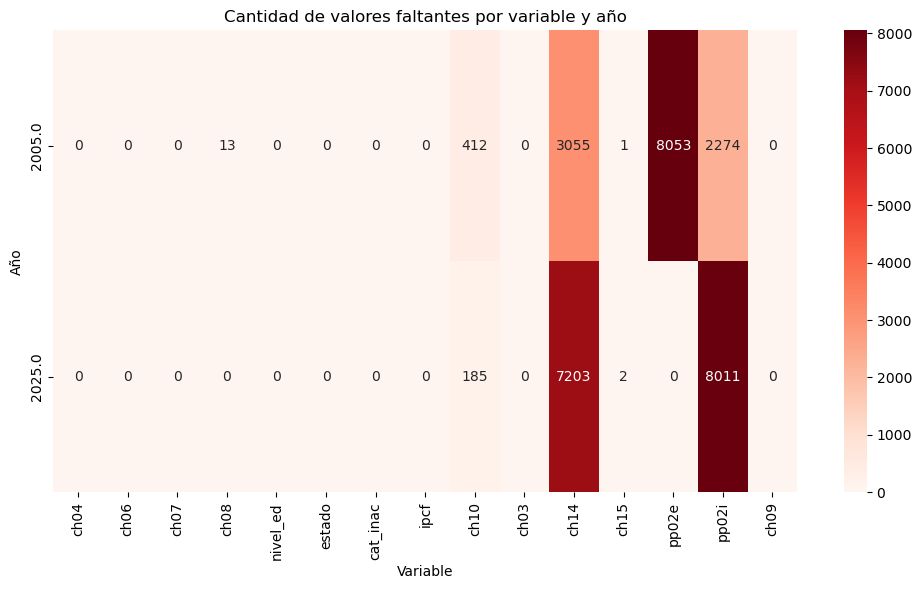

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las 15 variables de interés (excluyendo ano4)
variables = ["ch04", "ch06", "ch07", "ch08", "nivel_ed", "estado", 
             "cat_inac", "ipcf", "ch10", "ch03", "ch14", "ch15", 
             "pp02e", "pp02i", "ch09"]

# Tabla con la cantidad de valores faltantes por variable y año
missing_table = df_combinado.groupby('ano4')[variables].apply(lambda x: x.isna().sum())

print("Tabla de valores faltantes por año y variable:")
print(missing_table)

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(missing_table, annot=True, fmt="d", cmap="Reds")
plt.title("Cantidad de valores faltantes por variable y año")
plt.ylabel("Año")
plt.xlabel("Variable")
plt.show()

Las variables con más valores faltantes son: 
- pp02i del 2025
- ch14 del 2025
- pp02e del 2005
- ch14 del 2005

El proceso de limpieza de las variables se realizó anteriormente, guiandonos con los diccionarios de variables. Por ejemplo, cuando aparecía el valor 9, -9, 9999 se le asignó el valor Na, lo mismo ocurrió con algunas variables que presentaban el valor 0 y esta clasificación no aparecia en el diccionario. 

## **Parte II: Primer Análisis Exploratorio**

### **Punto 3** 

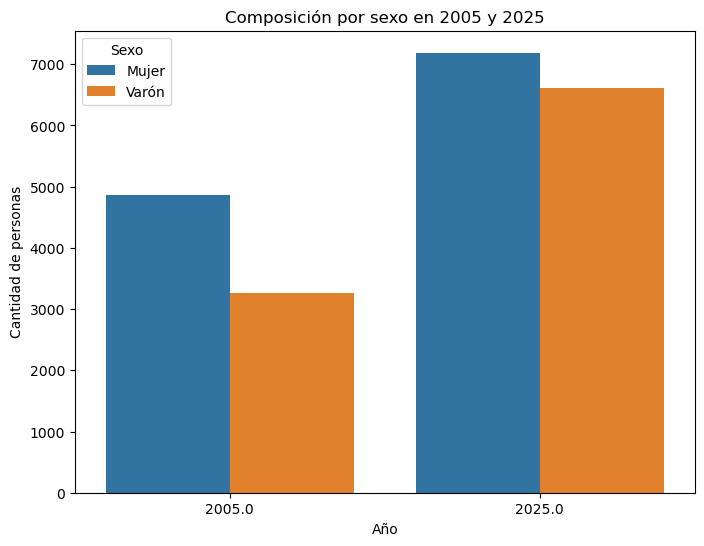

In [43]:
# Mapear los valores de ch04
df_combinado['sexo'] = df_combinado['ch04'].map({1: 'Varón', 2: 'Mujer'})

# Contar la cantidad de casos por sexo y año
sexo_counts = df_combinado.groupby(['ano4', 'sexo']).size().reset_index(name='count')

# Gráfico de barras
plt.figure(figsize=(8,6))
sns.barplot(data=sexo_counts, x='ano4', y='count', hue='sexo')
plt.title("Composición por sexo en 2005 y 2025")
plt.xlabel("Año")
plt.ylabel("Cantidad de personas")
plt.legend(title="Sexo")
plt.show()



In [44]:
# Mapeo de nivel_ed desde texto a números
map_nivel_ed_texto = {
    "Primario incompleto (incluye educación especial)": 1,
    "Primario completo": 2,
    "Secundario incompleto": 3,
    "Secundario completo": 4,
    "Superior y universitario incompleto": 5,
    "Superior y universitario completo": 6,
    "Sin instrucción": 7,
    "Ns/Nr": pd.NA  # poner NA
}

# Mapeo de estado desde texto a números
map_estado_texto = {
    "Entrevista individual no realizada (no respuesta al cuestionario individual)": pd.NA,
    "Ocupado": 1,
    "Desocupado": 2,
    "Inactivo": 3,
    "Menor de 10 años": 4
}

# Aplicarlo al DataFrame
df_combinado['nivel ed'] = df_combinado['nivel_ed'].map(map_nivel_ed_texto)
df_combinado['estado'] = df_combinado['estado'].map(map_estado_texto)


### **Punto 4** 

In [45]:
#Creamos dummys
d2005["mujer"] = (d2005["ch04"] == 2).astype(int)
d2005["hombre"] = (d2005["ch04"] == 1).astype(int)
d2025["mujer"] = (d2025["ch04"] == 2).astype(int)
d2025["hombre"] = (d2025["ch04"] == 1).astype(int)

In [46]:
d2005["unido_ch07"] = (d2005["ch07"] == 1).astype(int)
d2005["casado_ch07"] = (d2005["ch07"] == 2).astype(int)
d2005["separado_ch07"] = (d2005["ch07"] == 3).astype(int)
d2005["viudo_ch07"] = (d2005["ch07"] == 4).astype(int)
d2005["soltero_ch07"] = (d2005["ch07"] == 5).astype(int)

In [47]:
d2025["unido_ch07"] = (d2025["ch07"] == 1).astype(int)
d2025["casado_ch07"] = (d2025["ch07"] == 2).astype(int)
d2025["separado_ch07"] = (d2025["ch07"] == 3).astype(int)
d2025["viudo_ch07"] = (d2025["ch07"] == 4).astype(int)
d2025["soltero_ch07"] = (d2025["ch07"] == 5).astype(int)

In [48]:
# Lista de categorías con sus nombres claros
categorias_ch08 = {
    1: "obra_social_ch08",
    2: "mutual_ch08",
    3: "plan_publico_ch08",
    4: "sin_cobertura_ch08",
    12: "obra_mutual_emergencia_ch08",
    13: "obra_publico_ch08",
    23: "mutual_publico_ch08",
    123: "obra_mutual_emergencia_publico_ch08"
}

# Función para crear dummies, excluyendo Ns/Nr
def crear_dummies_ch08(df):
    for valor, nombre in categorias_ch08.items():
        df[nombre] = (df["ch08"] == valor).astype(int)
    return df

# Aplicar a los dos DataFrames
d2005 = crear_dummies_ch08(d2005)
d2025 = crear_dummies_ch08(d2025)


In [49]:
# Diccionario de categorías y nombres claros para dummies
categorias_nivel_ed = {
    1: "primario_incompleto",
    2: "primario_completo",
    3: "secundario_incompleto",
    4: "secundario_completo",
    5: "superior_incompleto",
    6: "superior_completo",
    7: "sin_instruccion"
    # 9 = Ns/Nr se omite
}

# Función para crear dummies de nivel educativo
def crear_dummies_nivel_ed(df):
    for valor, nombre in categorias_nivel_ed.items():
        df[nombre] = (df["nivel_ed"] == valor).astype(int)
    return df

# Aplicar a ambos DataFrames
d2005 = crear_dummies_nivel_ed(d2005)
d2025 = crear_dummies_nivel_ed(d2025)


In [50]:
d2005["estado"].unique

<bound method Series.unique of 29152    Menor de 10 años
29159    Menor de 10 años
29165            Inactivo
29167            Inactivo
29170    Menor de 10 años
               ...       
43795            Inactivo
43796            Inactivo
43797    Menor de 10 años
43798            Inactivo
43800            Inactivo
Name: estado, Length: 8135, dtype: category
Categories (5, object): ['Entrevista individual no realizada (no respue... < 'Ocupado' < 'Desocupado' < 'Inactivo' < 'Menor de 10 años']>

In [51]:
# Diccionario para mapear texto a números en d2005
map_estado_2005 = {
    "Entrevista individual no realizada (no respuesta al cuestionario individual)": pd.NA,
    "Ocupado": 1,
    "Desocupado": 2,
    "Inactivo": 3,
    "Menor de 10 años": 4
}

# Aplicar mapeo a d2005
d2005["estado_num"] = d2005["estado"].map(map_estado_2005)

# Para d2025, asumimos que ya está numérico
d2025["estado_num"] = d2025["estado"]


In [52]:
categorias_estado = {
    1: "ocupado",
    2: "desocupado",
    3: "inactivo",
    4: "menor_10"
    # 0 = entrevista no realizada → se puede dejar como NA o ignorar
}

def crear_dummies_estado(df):
    for valor, nombre in categorias_estado.items():
        df[nombre] = (df["estado_num"] == valor).astype(int)
    return df

# Aplicar a ambos DataFrames
d2005 = crear_dummies_estado(d2005)
d2025 = crear_dummies_estado(d2025)


In [53]:
d2005 = d2005.rename(columns={"ch06": "edad"})
d2025 = d2025.rename(columns={"ch06": "edad"})

In [54]:

#Creamos matrices de correlación
# Seleccionar columnas que son dummies según sufijos o nombres que definiste
columnas_dummy_2005 = [c for c in d2005.columns if 
                       any(suf in c for suf in ["casado_ch07", "soltero_ch07", "obra_social_ch08","sin_cobertura_ch08", "secundario_completo", "sin_instruccion",
                                            "inactivo","ipcf","edad","hombre","mujer"])]

columnas_dummy_2025 = [c for c in d2025.columns if 
                       any(suf in c for suf in ["casado_ch07", "soltero_ch07", "obra_social_ch08","sin_cobertura_ch08", "secundario_completo", "sin_instruccion",
                                                "inactivo","ipcf","edad","hombre","mujer"])]

# Mostrar lista de nombres
print("Dummies 2005:", columnas_dummy_2005)
print("Dummies 2025:", columnas_dummy_2025)


Dummies 2005: ['edad', 'ipcf', 'mujer', 'hombre', 'casado_ch07', 'soltero_ch07', 'obra_social_ch08', 'sin_cobertura_ch08', 'secundario_completo', 'sin_instruccion', 'inactivo']
Dummies 2025: ['edad', 'ipcf', 'mujer', 'hombre', 'casado_ch07', 'soltero_ch07', 'obra_social_ch08', 'sin_cobertura_ch08', 'secundario_completo', 'sin_instruccion', 'inactivo']


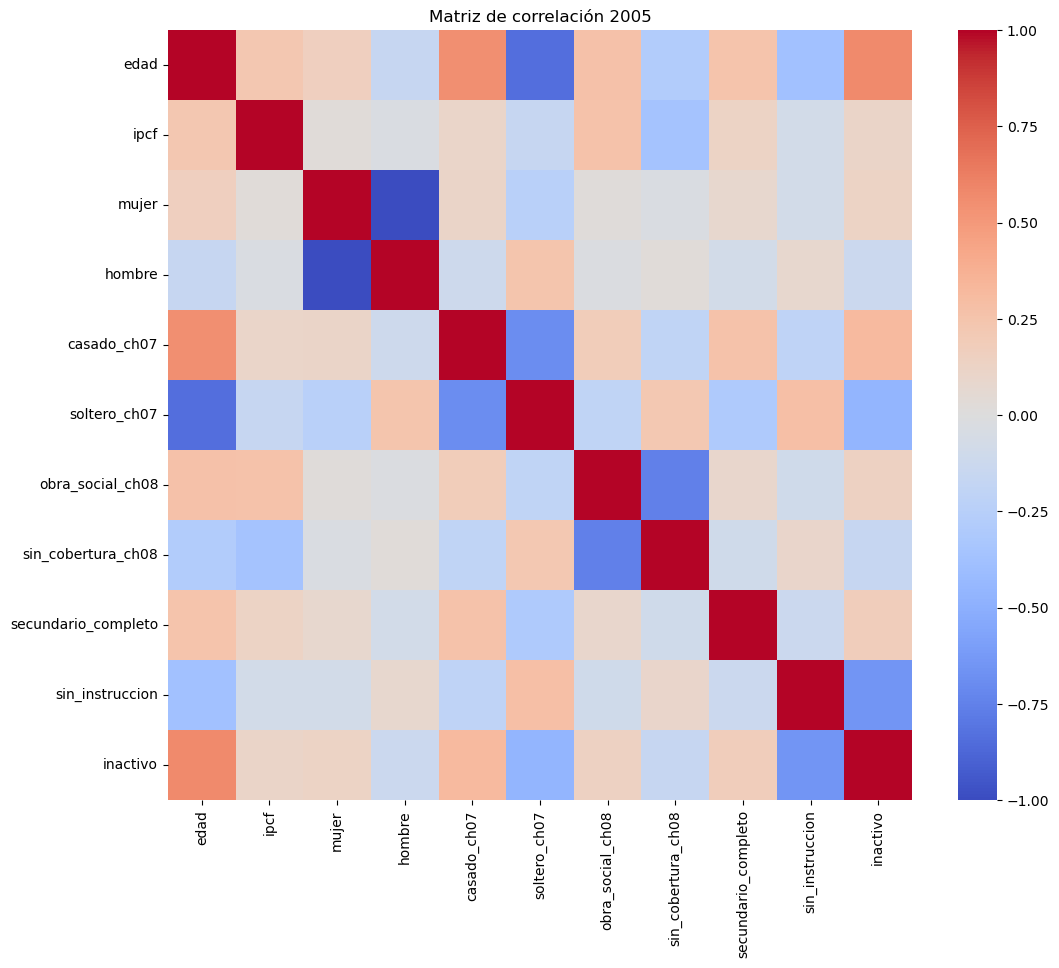

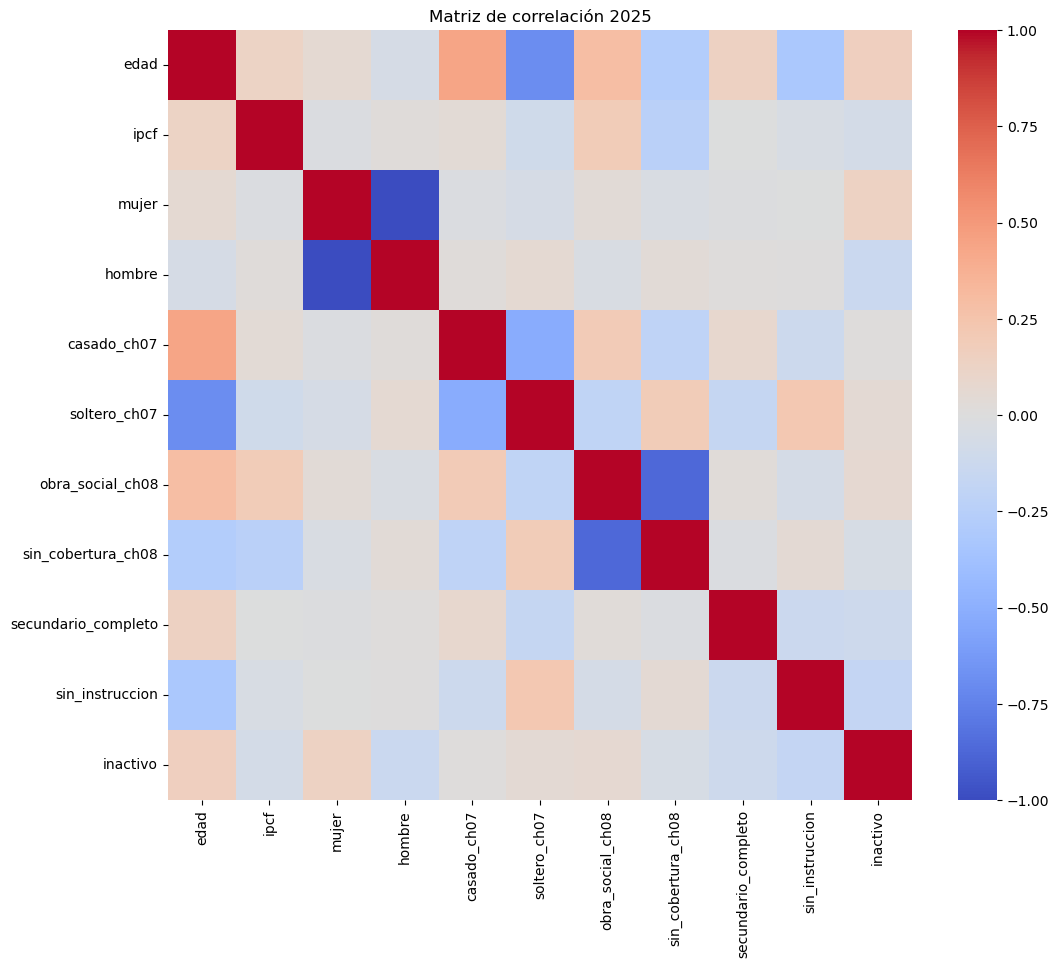

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Para la matriz, eliminamos los NA
df_corr_2005 = d2005[columnas_dummy_2005].dropna(axis=0)
df_corr_2025 = d2025[columnas_dummy_2025].dropna(axis=0)

# Calcular matriz de correlación
corr_2005 = df_corr_2005[columnas_dummy_2005].corr()
corr_2025 = df_corr_2025[columnas_dummy_2025].corr()

def graficar_correlacion(corr, titulo):
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=False, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title(titulo)
    plt.show()

# Graficar matrices
graficar_correlacion(corr_2005, "Matriz de correlación 2005")
graficar_correlacion(corr_2025, "Matriz de correlación 2025")


## **Parte III: Conociendo a los pobres y no pobres** 

### **Punto 5** 

In [56]:
# Usamos ipcf como proxy de ITF (en tu base combinada es la variable disponible)

# Base con los que no respondieron (ipcf = 0 o NA)
norespondieron = df_combinado[df_combinado["ipcf"].fillna(0) == 0].copy()

# Base con los que respondieron (ipcf distinto de 0)
respondieron = df_combinado[df_combinado["ipcf"].fillna(0) != 0].copy()

print("Cantidad de personas con ipcf = 0 (no respondieron):", norespondieron.shape[0])
print("Cantidad de personas con ipcf ≠ 0 (respondieron):", respondieron.shape[0])

# Guardar como archivos separados (opcional)
norespondieron.to_excel("norespondieron.xlsx", index=False)
respondieron.to_excel("respondieron.xlsx", index=False)


Cantidad de personas con ipcf = 0 (no respondieron): 4568
Cantidad de personas con ipcf ≠ 0 (respondieron): 17368


### **Punto 6** 

In [57]:
respondieron.head()

,ano4,ch04,ch06,ch07,ch08,nivel_ed,estado,cat_inac,ipcf,ch10,ch03,ch14,ch15,pp02e,pp02i,ch09,codusu,sexo,nivel ed
0,2005.0,1,4.0,5,1,7,4,5.0,280.000000,1,3,1,1,<NA>,<NA>,2,125082,Varón,NaN
1,2005.0,2,1.0,5,12,7,4,5.0,400.000000,<NA>,3,<NA>,1,<NA>,<NA>,3,125409,Mujer,NaN
2,2005.0,2,78.0,4,1,6,3,1.0,3200.000000,2,1,<NA>,1,<NA>,2,1,126610,Mujer,NaN
3,2005.0,1,16.0,5,1,3,3,3.0,435.000000,1,3,2,1,<NA>,2,1,126653,Varón,NaN
4,2005.0,1,-1.0,5,1,7,4,5.0,517.333333,<NA>,3,<NA>,1,<NA>,<NA>,3,126852,Varón,NaN


In [58]:
adulto_equiv=pd.read_excel("C:/Users/loloa/OneDrive/Escritorio/facu/Ciencia de datos/tp/Ciencia-de-Datos/tabla_adulto_equiv.xlsx")
respondieron = respondieron.rename(columns={"ch06": "edad"})
#modifique adulto equiv desde excel para poder llamarlo fácil y que las variables correspondan
#cambie para que haya una row por edad y no por rango
def expand_row(row):
    edad = row["Edad"]
    if isinstance(edad, str) and "-" in edad:
        start, end = map(int, edad.split("-"))
        return pd.DataFrame({
            "Edad": range(start, end + 1),
            "Mujeres": row["Mujeres"],
            "Varones": row["Varones"]
        })
    else:
        return pd.DataFrame({
            "Edad": [int(edad)],
            "Mujeres": [row["Mujeres"]],
            "Varones": [row["Varones"]]
        })
adulto_equiv = pd.concat([expand_row(r) for _, r in adulto_equiv.iterrows()],
                                  ignore_index=True)

#estandarize las variables
adulto_equiv = adulto_equiv.rename(columns={
    "Edad": "edad",
    "Mujeres": "Mujer",
    "Varones": "Varón"
})
#cambie el formato de adulto_equiv para poder mergear
adulto_equiv_long = adulto_equiv.melt(
    id_vars=["edad"], 
    value_vars=["Mujer", "Varón"],
    var_name="sexo", 
    value_name="adulto_equiv"
)

respondieron = respondieron.merge(
    adulto_equiv_long,
    on=["edad", "sexo"],
    how="left"   
)
print(respondieron.head())
print(adulto_equiv_long.head() )

     ano4  ch04  edad  ch07  ch08  nivel_ed estado  cat_inac         ipcf  \
0  2005.0     1   4.0     5     1         7      4       5.0   280.000000   
1  2005.0     2   1.0     5    12         7      4       5.0   400.000000   
2  2005.0     2  78.0     4     1         6      3       1.0  3200.000000   
3  2005.0     1  16.0     5     1         3      3       3.0   435.000000   
4  2005.0     1  -1.0     5     1         7      4       5.0   517.333333   

   ch10  ch03  ch14  ch15  pp02e  pp02i  ch09    codusu   sexo nivel ed  \
0     1     3     1     1   <NA>   <NA>     2  125082    Varón      NaN   
1  <NA>     3  <NA>     1   <NA>   <NA>     3  125409    Mujer      NaN   
2     2     1  <NA>     1   <NA>      2     1  126610    Mujer      NaN   
3     1     3     2     1   <NA>      2     1  126653    Varón      NaN   
4  <NA>     3  <NA>     1   <NA>   <NA>     3  126852    Varón      NaN   

   adulto_equiv  
0          0.55  
1          0.37  
2          0.63  
3          1.0

In [59]:
respondieron = respondieron.rename(columns={"edad": "ch06"})

In [60]:
respondieron["ad_equiv_hogar"] = (
    respondieron.groupby("codusu")["adulto_equiv"]
    .transform("sum")
)
print(respondieron.head())
#agregaamos necesidades energeticas por hogar

     ano4  ch04  ch06  ch07  ch08  nivel_ed estado  cat_inac         ipcf  \
0  2005.0     1   4.0     5     1         7      4       5.0   280.000000   
1  2005.0     2   1.0     5    12         7      4       5.0   400.000000   
2  2005.0     2  78.0     4     1         6      3       1.0  3200.000000   
3  2005.0     1  16.0     5     1         3      3       3.0   435.000000   
4  2005.0     1  -1.0     5     1         7      4       5.0   517.333333   

   ch10  ...  ch14  ch15  pp02e  pp02i  ch09    codusu   sexo nivel ed  \
0     1  ...     1     1   <NA>   <NA>     2  125082    Varón      NaN   
1  <NA>  ...  <NA>     1   <NA>   <NA>     3  125409    Mujer      NaN   
2     2  ...  <NA>     1   <NA>      2     1  126610    Mujer      NaN   
3     1  ...     2     1   <NA>      2     1  126653    Varón      NaN   
4  <NA>  ...  <NA>     1   <NA>   <NA>     3  126852    Varón      NaN   

  adulto_equiv  ad_equiv_hogar  
0         0.55            0.55  
1         0.37            

In [61]:
print((respondieron["ad_equiv_hogar"] == respondieron["adulto_equiv"]).value_counts())
 # chequeamos que los iguales sean porque viven solos

False    14903
True      2465
Name: count, dtype: int64


### **Punto 7** 

In [62]:
import numpy as np
# 1) Asegurar tipos numéricos (por las dudas)
respondieron["ad_equiv_hogar"] = pd.to_numeric(respondieron["ad_equiv_hogar"], errors="coerce")
respondieron["ano4"] = pd.to_numeric(respondieron["ano4"], errors="coerce")

# 2) Calcular ingreso_necesario (tu bloque)
CBT_2025 = 365_177.0
CBT_2005 = 205.07
respondieron["ingreso_necesario"] = np.where(
    respondieron["ano4"] == 2025,
    respondieron["ad_equiv_hogar"] * CBT_2025,
    respondieron["ad_equiv_hogar"] * CBT_2005
)

# 3) Vistazo rápido
print(respondieron[["ano4","ad_equiv_hogar","ingreso_necesario"]].head())
print(respondieron.groupby("ano4")["ingreso_necesario"].describe().round(2))


     ano4  ad_equiv_hogar  ingreso_necesario
0  2005.0            0.55           112.7885
1  2005.0            0.37            75.8759
2  2005.0            0.63           129.1941
3  2005.0            1.03           211.2221
4  2005.0            0.35            71.7745
         count        mean        std        min        25%        50%  \
ano4                                                                     
2005.0  8028.0      447.41     268.07      71.77     274.79     381.43   
2025.0  9340.0  1019449.07  523129.81  230061.51  642711.52  949460.20   

               75%         max  
ano4                            
2005.0      582.40     1978.93  
2025.0  1303681.89  4177624.88  


### **Punto 8** 

In [63]:
# Asegurar tipos
respondieron["ipcf"] = pd.to_numeric(respondieron["ipcf"], errors="coerce")
respondieron["ingreso_necesario"] = pd.to_numeric(respondieron["ingreso_necesario"], errors="coerce")

# Variable pobre (proxy con ipcf, ver nota metodológica)
respondieron["pobre"] = (respondieron["ipcf"] < respondieron["ingreso_necesario"]).astype(int)

# Conteo por año (denominador = cantidad con ipcf válido en 'respondieron')
res = (respondieron
       .dropna(subset=["ipcf","ingreso_necesario"])
       .groupby("ano4")
       .agg(n_pobres=("pobre","sum"),
            n_obs=("pobre","size"))
       .reset_index())
res["pct_pobres"] = (res["n_pobres"] / res["n_obs"] * 100).round(2)

print("Pobreza (conteo y % sobre la muestra con ipcf válido):")
print(res)


Pobreza (conteo y % sobre la muestra con ipcf válido):
     ano4  n_pobres  n_obs  pct_pobres
0  2005.0      5157   8028       64.24
1  2025.0      7099   9340       76.01


### **Punto 9** 

Estadísticas descriptivas de 'pobre' por año:
         count   mean    std  min  25%  50%  75%  max
ano4                                                 
2005.0  8028.0  0.642  0.479  0.0  0.0  1.0  1.0  1.0
2025.0  9340.0  0.760  0.427  0.0  1.0  1.0  1.0  1.0


C:\Users\loloa\AppData\Local\Temp\ipykernel_15612\312561244.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pobre_pct, x="ano4", y="pobre", palette="Set2")


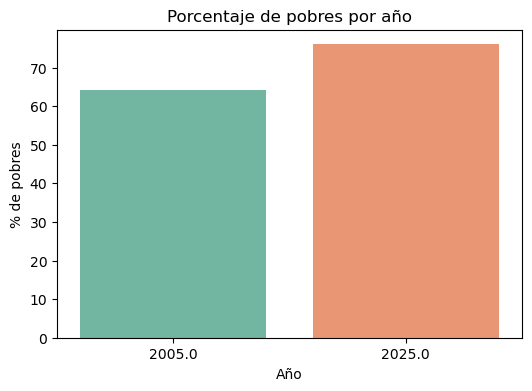

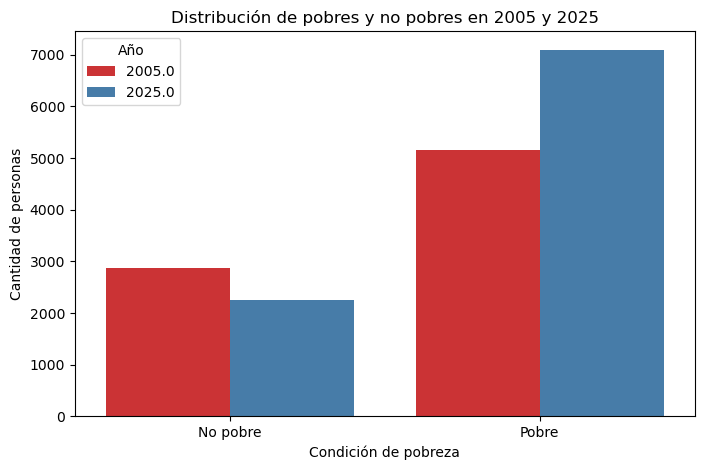

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Tabla descriptiva ---
desc_pobre = respondieron.groupby("ano4")["pobre"].describe().round(3)
print("Estadísticas descriptivas de 'pobre' por año:")
print(desc_pobre)

# --- Gráfico 1: Barras con % de pobres por año ---
pobre_pct = respondieron.groupby("ano4")["pobre"].mean().reset_index()
pobre_pct["pobre"] = pobre_pct["pobre"] * 100

plt.figure(figsize=(6,4))
sns.barplot(data=pobre_pct, x="ano4", y="pobre", palette="Set2")
plt.ylabel("% de pobres")
plt.xlabel("Año")
plt.title("Porcentaje de pobres por año")
plt.show()

# --- Gráfico 2: Countplot pobreza (0=No pobre, 1=Pobre) por año ---
plt.figure(figsize=(8,5))
sns.countplot(data=respondieron, x="pobre", hue="ano4", palette="Set1")
plt.xticks([0,1], ["No pobre", "Pobre"])
plt.xlabel("Condición de pobreza")
plt.ylabel("Cantidad de personas")
plt.title("Distribución de pobres y no pobres en 2005 y 2025")
plt.legend(title="Año")
plt.show()


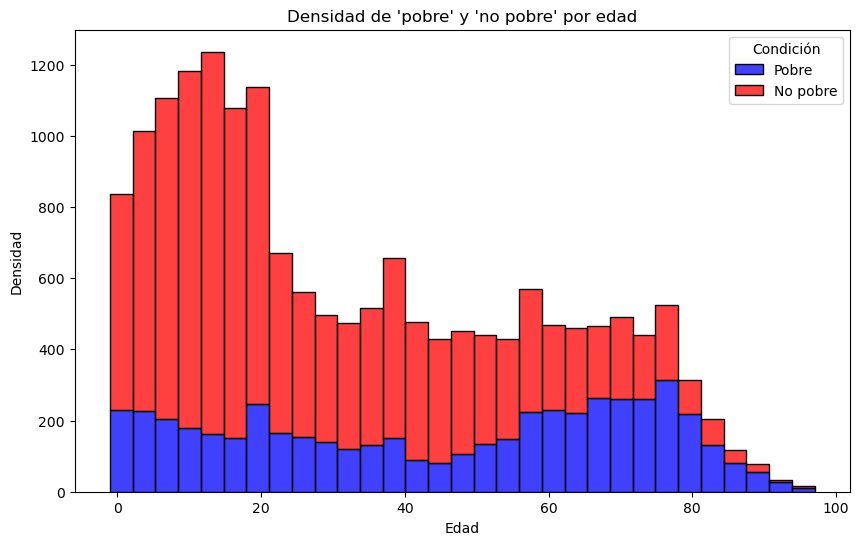

In [ ]:
respondieron["ch06"]=respondieron["ch06"].astype(float)
respondieron["edad2"]=respondieron["ch06"]**2
# Create a histogram showing the density of "pobre" and "no pobre" for each "edad"
plt.figure(figsize=(10, 6))
sns.histplot(
    data=respondieron,
    x="ch06",
    hue="pobre",
    multiple="stack",
    kde=False,
    palette={1: "red", 0: "blue"},
    hue_order=[1, 0]
)
plt.xlabel("Edad")
plt.ylabel("Densidad")
plt.title("Densidad de 'pobre' y 'no pobre' por edad")
plt.legend(title="Condición", labels=["Pobre", "No pobre"])
plt.show()
#hmmmmm